### Libraries

In [16]:
import os
import glob
import nibabel as nb
import scipy.stats
from brainspace.mesh.mesh_io import read_surface
from brainspace.plotting import plot_hemispheres
from brainspace.gradient import GradientMaps
from brainspace.mesh.array_operations import smooth_array
import numpy as np
import seaborn as sns
import pandas as pd
import cmocean
import matplotlib.pyplot as plt
import matplotlib as mpl
from brainspace.datasets import load_mask
from matplotlib.lines import Line2D
import colormaps as clrmps
import matplotlib.cm as cm
from cmcrameri import cm

### Variables

In [3]:
# Set dataset PNI as working directory
os.chdir('/data_/mica3/BIDS_PNI/derivatives/micapipe_v0.2.0')

# Path to MICAPIPEsurf = mask_5k !
micapipe=os.popen("echo $MICAPIPE").read()[:-1]

# Load native mid surface
inf_lh = read_surface(micapipe + '/surfaces/fsLR-5k.L.inflated.surf.gii', itype='gii')
inf_rh = read_surface(micapipe + '/surfaces/fsLR-5k.R.inflated.surf.gii', itype='gii')

mask_lh =  nb.load(micapipe + '/surfaces/fsLR-5k.R.mask.shape.gii').darrays[0].data
mask_rh =  nb.load(micapipe + '/surfaces/fsLR-5k.L.mask.shape.gii').darrays[0].data
mask_5k = np.concatenate((mask_lh, mask_rh), axis=0)

# Load fsLR 5k
f5k_lh = read_surface(micapipe + '/surfaces/fsLR-5k.L.surf.gii', itype='gii')
f5k_rh = read_surface(micapipe + '/surfaces/fsLR-5k.R.surf.gii', itype='gii')

# Load fsLR 32k
f32k_lh = read_surface(micapipe + '/surfaces/fsLR-32k.L.surf.gii', itype='gii')
f32k_rh = read_surface(micapipe + '/surfaces/fsLR-32k.R.surf.gii', itype='gii')
# Load fsLR 32k inflated
f32k_inf_lh = read_surface(micapipe + '/surfaces/fsLR-32k.L.inflated.surf.gii', itype='gii')
f32k_inf_rh = read_surface(micapipe + '/surfaces/fsLR-32k.R.inflated.surf.gii', itype='gii')
mask_32k = load_mask(join=True)

# Boolean mask
#mask_surf = mask_5k != 0
mask_surf = mask_32k != 0

### Functions

In [4]:
# Function: Smooth intensity profiles on a given surface
def smooth_surf(surf_l, surf_r, points, Mask, Kernel='uniform', Niter=3, Relax=0.35):
    '''
    Smooths intensity data on a given surface mesh using iterative smoothing.
    
    Parameters:
    -----------
    surf_l : np.array
        Left hemisphere surface connectivity.
    surf_r : np.array
        Right hemisphere surface connectivity.
    points : np.array
        Intensity profile data mapped to the surface.
    Mask : np.array
        Binary mask indicating valid regions for smoothing.
    Kernel : str, optional
        Smoothing kernel type, options: {'uniform', 'gaussian', 'inverse_distance'}.
    Niter : int, optional
        Number of smoothing iterations (default: 3).
    Relax : float, optional
        Relaxation factor controlling smoothing intensity (default: 0.35).
    
    Returns:
    --------
    sdata : np.array
        Smoothed intensity data.
    '''
    Ndim = Mask.shape[0] 
    n2dim = int(Ndim/2)
    Mask_l = Mask[:n2dim]
    Mask_r = Mask[n2dim:]
    
    sdata = np.concatenate((
        smooth_array(surf_l, points[:n2dim], kernel=Kernel, n_iter=Niter, relax=Relax, mask=Mask_l), 
        smooth_array(surf_r, points[n2dim:], kernel=Kernel, n_iter=Niter, relax=Relax, mask=Mask_r)
    ), axis=0)
    
    return sdata

# Function: Apply smoothing to intensity profiles across all depths
def smooth_intensities(int_profile):
    '''
    Applies surface smoothing to each depth of the intensity profile.
    
    Parameters:
    -----------
    int_profile : np.array
        Input intensity profiles, where rows represent different depths.
    
    Returns:
    --------
    smoothed_i : np.array
        Smoothed intensity profiles.
    '''
    smoothed_i = np.copy(int_profile)
    
    for i in range(int_profile.shape[0]):
        smoothed_i[i, :] = smooth_surf(
            f32k_inf_lh, f32k_inf_rh, int_profile[i, :], mask_surf, Niter=5, Relax=0.5, Kernel='uniform'
        )
    
    return smoothed_i

In [5]:
def fill_missing_Turkey(cdata):
    # Calculate the first and third quartiles
    Q1 = np.nanpercentile(cdata, 25)
    Q3 = np.nanpercentile(cdata, 75)

    # Calculate the interquartile range (IQR)
    IQR = Q3 - Q1

    # Define the outlier thresholds based on Tukey's method
    lower_threshold = Q1 - 1.5 * IQR
    upper_threshold = Q3 + 1.5 * IQR

    # Identify outliers based on Tukey's method
    outliers = (cdata < lower_threshold) | (cdata > upper_threshold)

    # Set outliers to NaN
    cdata[outliers] = np.nan

    # Interpolate NaNs
    good = np.where(~np.isnan(cdata))
    bad = np.where(np.isnan(cdata))
    fill = scipy.interpolate.griddata(good, cdata[good], bad)
    cdata[bad] = fill

    # Extrapolate any remaining missing values
    good = np.where(~np.isnan(cdata))
    bad = np.where(np.isnan(cdata))
    fill = scipy.interpolate.griddata(good, cdata[good], bad, method='nearest')
    cdata[bad] = fill
    
    return cdata

## AFD - parallel (long range fibres)

In [6]:
base_dir = '/host/verges/tank/data/youngeun/myproject/FBA/3T_7T/subjects_csd'
subject_dirs = [
    'PNC003_HC082', 'PNC006_HC081', 'PNC011_HC083', 'PNC018_HC076',
    'PNC019_HC062', 'PNC022_HC132', 'PNC024_HC088', 'PNC025_HC128',
    'PNC026_HC130', 'PNC037_HC116', 'PNC038_HC140'
]

In [13]:
all_par_SWM = []

for subj in subject_dirs:
    subj_path = os.path.join(base_dir, subj, 'csd_msmt')
    lh_path = os.path.join(subj_path, 'L_fsLR32k_afd-par_5mm.txt')
    #lh_path = os.path.join(subj_path, 'test_par.txt')
    rh_path = os.path.join(subj_path, 'R_fsLR32k_afd-par_5mm.txt')

    try:
        lh_par = np.loadtxt(lh_path)
        rh_par = np.loadtxt(rh_path)

        # column 0 (0mm), 2 (1mm), 4 (2mm)
        par_0mm = np.concatenate((lh_par[:, 0], rh_par[:, 0]), axis=0)
        #par_0p5mm = np.concatenate((lh_par[:, 1], rh_par[:, 1]), axis=0)
        par_1mm = np.concatenate((lh_par[:, 2], rh_par[:, 2]), axis=0)
        #par_1p5mm = np.concatenate((lh_par[:, 3], rh_par[:, 3]), axis=0)
        par_2mm = np.concatenate((lh_par[:, 4], rh_par[:, 4]), axis=0)
        #par_2p5mm = np.concatenate((lh_par[:, 5], rh_par[:, 5]), axis=0)
        par_3mm = np.concatenate((lh_par[:, 6], rh_par[:, 6]), axis=0)

        # Convert -1 to NaN for missing values
        par_0mm[par_0mm == -1] = np.nan
        #par_0p5mm[par_0p5mm == -1] = np.nan
        par_1mm[par_1mm == -1] = np.nan
        #par_1p5mm[par_1p5mm == -1] = np.nan
        par_2mm[par_2mm == -1] = np.nan
        #par_2p5mm[par_2p5mm == -1] = np.nan
        par_3mm[par_3mm == -1] = np.nan

        par_SWM = np.vstack([par_0mm, par_1mm, par_2mm, par_3mm])  # shape: (3, vertices)
        #par_SWM = np.vstack([par_0mm, par_0p5mm, par_1mm, par_1p5mm, par_2mm, par_2p5mm, par_3mm])  # shape: (3, vertices)

        # Fill missing data using Turkey's method
        filled_matrix = np.empty_like(par_SWM)
        for i, row in enumerate(par_SWM):
            filled_matrix[i] = fill_missing_Turkey(row)

        par_smooth = smooth_intensities(filled_matrix)
        
        all_par_SWM.append(par_smooth)
    except Exception as e:
        print(f"Error loading subject {subj}: {e}")

# shape: (n_subjects, 3, vertices)
all_par_SWM = np.stack(all_par_SWM, axis=0)
mean_par_SWM = np.nanmean(all_par_SWM, axis=0)  # shape: (3, vertices)

In [10]:
np.save('/host/verges/tank/data/youngeun/myjupyter/array/AFD_par_allsubs.npy', all_par_SWM)

In [8]:
np.save('/host/verges/tank/data/youngeun/myjupyter/array/AFD_par_average_7surf.npy', mean_par_SWM)

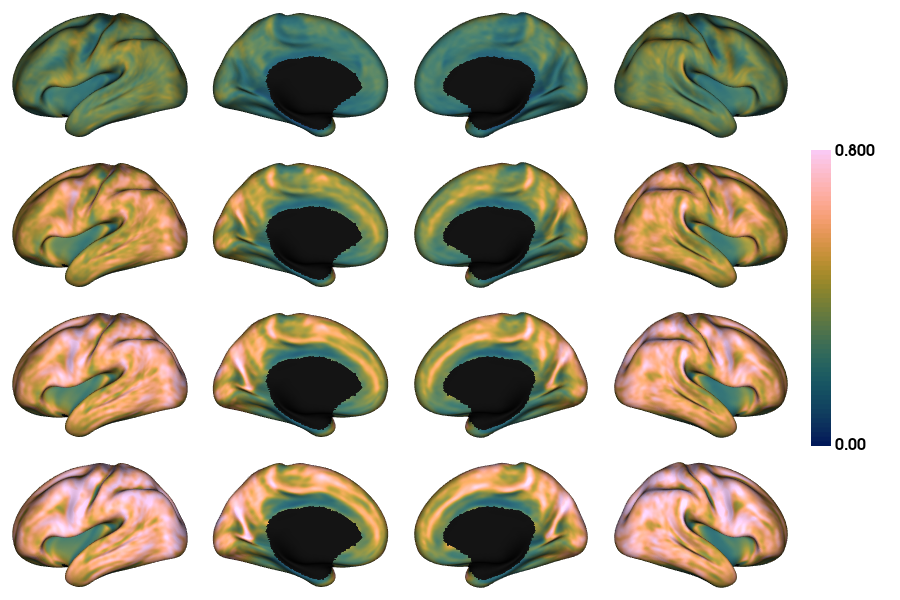

In [17]:
mean_par_SWM[:,mask_32k == False] = np.nan
plot_hemispheres(f32k_inf_lh, f32k_inf_rh, array_name=mean_par_SWM, size=(900, 600), color_bar='right', zoom=1.5, embed_nb=True, interactive=False, share='both', nan_color=(0, 0, 0, 1), 
                 cmap='cmc.batlow', transparent_bg=False, screenshot=False, color_range=(0,0.8))

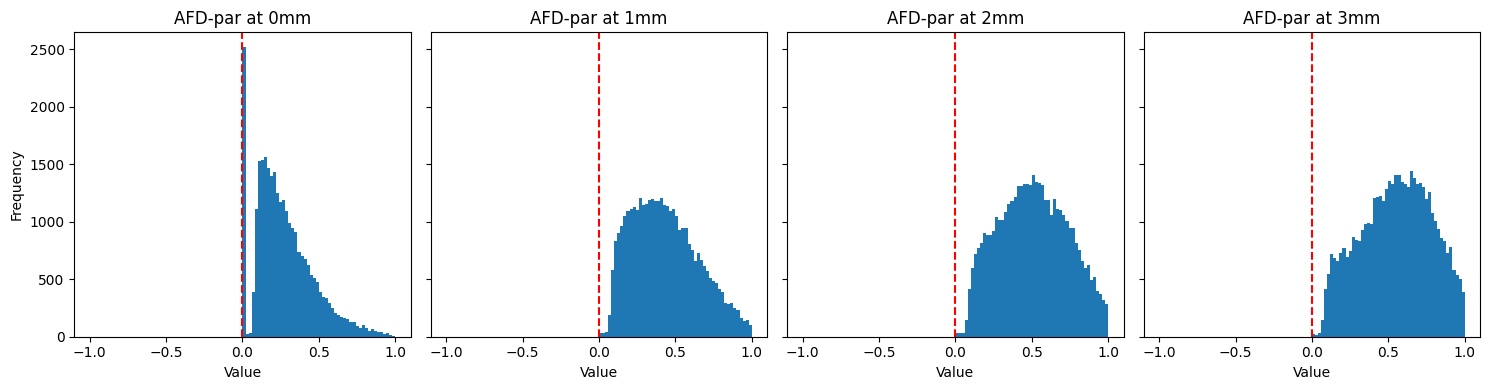

In [15]:
# Create the figure and axes
fig, axes = plt.subplots(1, 4, figsize=(15, 4), sharey=True)

# Your data (assuming they are 1D arrays or lists)
datasets = [par_0mm, par_1mm, par_2mm, par_3mm]
titles = ["AFD-par at 0mm", "AFD-par at 1mm", "AFD-par at 2mm", "AFD-par at 3mm"]

# Loop over each subplot
for i, ax in enumerate(axes):
    ax.hist(datasets[i], bins=100, range=(-1, 1))
    ax.axvline(0, color='red', linestyle='--')
    ax.set_title(titles[i])
    ax.set_xlabel("Value")
    if i == 0:
        ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

## AFD - perpendicular

In [23]:
all_perp_SWM = []

for subj in subject_dirs:
    subj_path = os.path.join(base_dir, subj, 'csd_msmt')
    lh_path = os.path.join(subj_path, 'L_fsLR32k_afd-perp.txt')
    rh_path = os.path.join(subj_path, 'R_fsLR32k_afd-perp.txt')

    try:
        lh_perp = np.loadtxt(lh_path)
        rh_perp = np.loadtxt(rh_path)

        # column 0 (0mm), 2 (1mm), 4 (2mm)
        perp_0mm = np.concatenate((lh_perp[:, 0], rh_perp[:, 0]), axis=0)
        perp_1mm = np.concatenate((lh_perp[:, 2], rh_perp[:, 2]), axis=0)
        perp_2mm = np.concatenate((lh_perp[:, 5], rh_perp[:, 5]), axis=0)

        # Convert -1 to NaN for missing values
        perp_0mm[perp_0mm == -1] = np.nan
        perp_1mm[perp_1mm == -1] = np.nan
        perp_2mm[perp_2mm == -1] = np.nan
        
        perp_SWM = np.vstack([perp_0mm, perp_1mm, perp_2mm])  # shape: (3, vertices)

        # Fill missing data using Turkey's method
        filled_matrix = np.empty_like(perp_SWM)
        for i, row in enumerate(perp_SWM):
            filled_matrix[i] = fill_missing_Turkey(row)

        perp_smooth = smooth_intensities(filled_matrix)
        
        all_perp_SWM.append(perp_smooth)
    except Exception as e:
        print(f"Error loading subject {subj}: {e}")

# shape: (n_subjects, 3, vertices)
all_perp_SWM = np.stack(all_perp_SWM, axis=0)
mean_perp_SWM = np.nanmean(all_perp_SWM, axis=0)  # shape: (3, vertices)

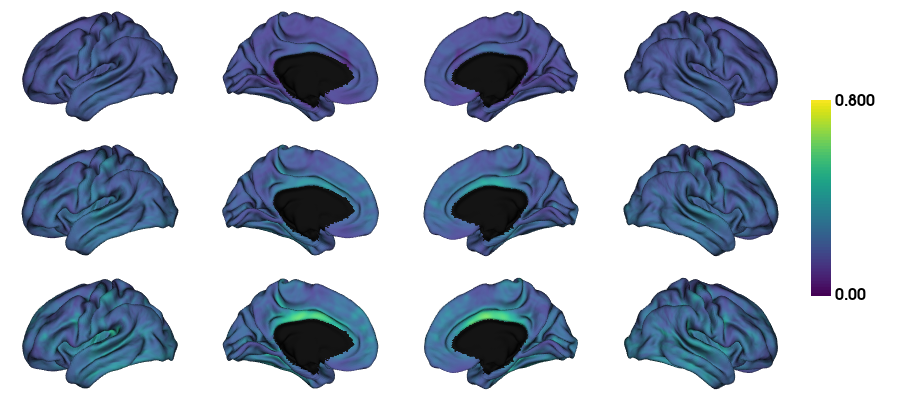

In [24]:
mean_perp_SWM[:,mask_32k == False] = np.nan
plot_hemispheres(f32k_lh, f32k_rh, array_name=mean_perp_SWM, size=(900, 400), color_bar='right', zoom=1.5, embed_nb=True, interactive=False, share='both', nan_color=(0, 0, 0, 1), 
                 cmap='viridis', transparent_bg=False, screenshot=False, color_range=(0,0.8))

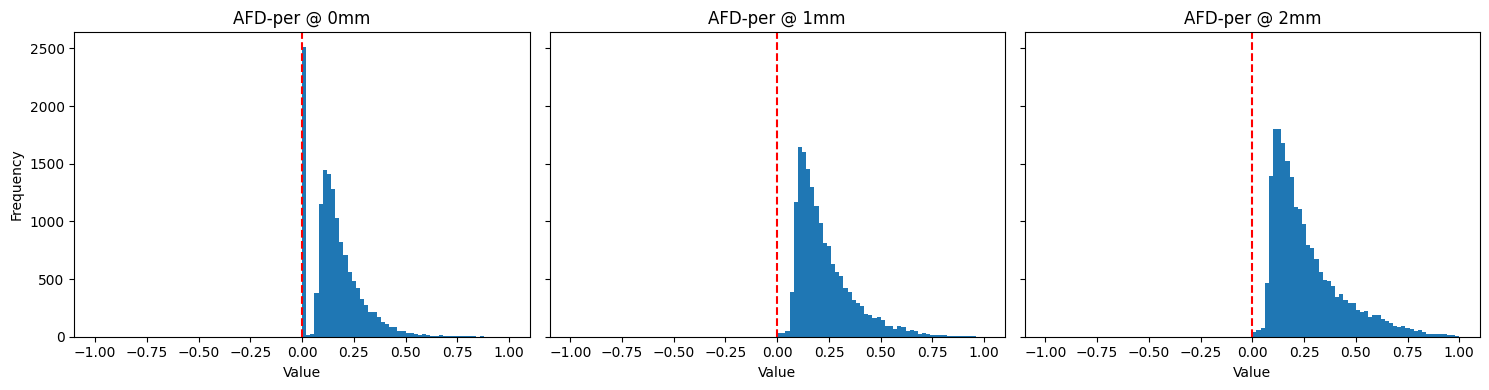

In [25]:
# Create the figure and axes
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

# Your data (assuming they are 1D arrays or lists)
datasets = [perp_0mm, perp_1mm, perp_2mm]
titles = ["AFD-per @ 0mm", "AFD-per @ 1mm", "AFD-per @ 2mm"]

# Loop over each subplot
for i, ax in enumerate(axes):
    ax.hist(datasets[i], bins=100, range=(-1, 1))
    ax.axvline(0, color='red', linestyle='--')
    ax.set_title(titles[i])
    ax.set_xlabel("Value")
    if i == 0:
        ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

## AFD - perpendicular-average (u-fibers)

In [19]:
all_perpav_SWM = []

for subj in subject_dirs:
    subj_path = os.path.join(base_dir, subj, 'csd_msmt')
    lh_path = os.path.join(subj_path, 'L_fsLR32k_afd-perp-av_5mm.txt')
    rh_path = os.path.join(subj_path, 'R_fsLR32k_afd-perp-av_5mm.txt')

    try:
        lh_perpav = np.loadtxt(lh_path)
        rh_perpav = np.loadtxt(rh_path)

        # column 0 (0mm), 2 (1mm), 4 (2mm)
        perpav_0mm = np.concatenate((lh_perpav[:, 0], rh_perpav[:, 0]), axis=0)
        perpav_0p5mm = np.concatenate((lh_perpav[:, 1], rh_perpav[:, 1]), axis=0)
        perpav_1mm = np.concatenate((lh_perpav[:, 2], rh_perpav[:, 2]), axis=0)
        perpav_1p5mm = np.concatenate((lh_perpav[:, 3], rh_perpav[:, 3]), axis=0)
        perpav_2mm = np.concatenate((lh_perpav[:, 4], rh_perpav[:, 4]), axis=0)
        perpav_2p5mm = np.concatenate((lh_perpav[:, 5], rh_perpav[:, 5]), axis=0)
        perpav_3mm = np.concatenate((lh_perpav[:, 6], rh_perpav[:, 6]), axis=0)

        # Convert -1 to NaN for missing values
        perpav_0mm[perpav_0mm == -1] = np.nan
        perpav_0p5mm[perpav_0p5mm == -1] = np.nan
        perpav_1mm[perpav_1mm == -1] = np.nan
        perpav_1p5mm[perpav_1p5mm == -1] = np.nan
        perpav_2mm[perpav_2mm == -1] = np.nan
        perpav_2p5mm[perpav_2p5mm == -1] = np.nan
        perpav_3mm[perpav_3mm == -1] = np.nan

        perpav_SWM = np.vstack([perpav_0mm, perpav_1mm, perpav_2mm, perpav_3mm])  # shape: (3, vertices)
        #perpav_SWM = np.vstack([perpav_0mm, perpav_0p5mm, perpav_1mm, perpav_1p5mm, perpav_2mm, perpav_2p5mm, perpav_3mm])  # shape: (3, vertices)

        # Fill missing data using Turkey's method
        filled_matrix = np.empty_like(perpav_SWM)
        for i, row in enumerate(perpav_SWM):
            filled_matrix[i] = fill_missing_Turkey(row)

        perpav_smooth = smooth_intensities(filled_matrix)
        
        all_perpav_SWM.append(perpav_smooth)
    except Exception as e:
        print(f"Error loading subject {subj}: {e}")

# shape: (n_subjects, 3, vertices)
all_perpav_SWM = np.stack(all_perpav_SWM, axis=0)
mean_perpav_SWM = np.nanmean(all_perpav_SWM, axis=0)  # shape: (3, vertices)

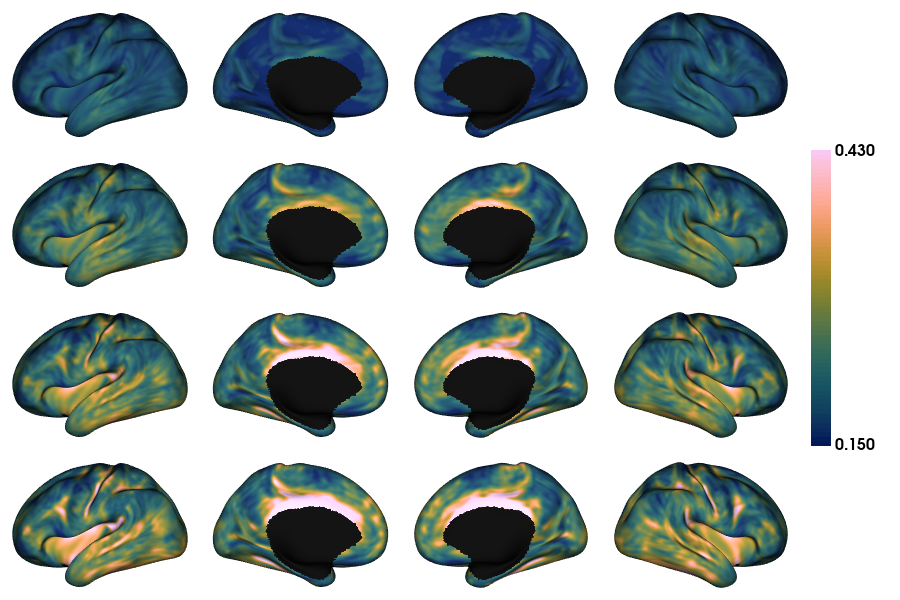

In [20]:
mean_perpav_SWM[:,mask_32k == False] = np.nan
plot_hemispheres(f32k_inf_lh, f32k_inf_rh, array_name=mean_perpav_SWM, size=(900, 600), color_bar='right', zoom=1.5, embed_nb=True, interactive=False, share='both', nan_color=(0, 0, 0, 1), 
                 cmap='cmc.batlow', transparent_bg=False, screenshot=False, color_range=(0.15,0.43))

In [18]:
np.save('/host/verges/tank/data/youngeun/myjupyter/array/AFD_perpav_allsubs.npy', all_perpav_SWM)

In [14]:
np.save('/host/verges/tank/data/youngeun/myjupyter/array/AFD_perpav_average.npy', mean_perpav_SWM)

In [10]:
np.save('/host/verges/tank/data/youngeun/myjupyter/array/AFD_perpav_average_7surf.npy', mean_perpav_SWM)

## F1: Intensity Smoothing

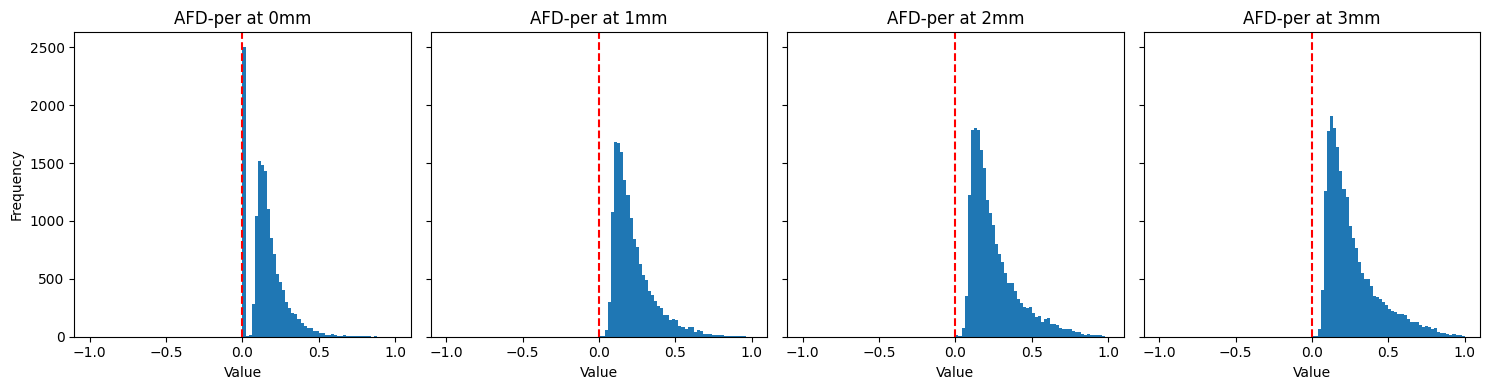

In [20]:
# Create the figure and axes
fig, axes = plt.subplots(1, 4, figsize=(15, 4), sharey=True)

# Your data (assuming they are 1D arrays or lists)
datasets = [perpav_0mm, perpav_1mm, perpav_2mm, perpav_3mm]
titles = ["AFD-per at 0mm", "AFD-per at 1mm", "AFD-per at 2mm", "AFD-per at 3mm"]

# Loop over each subplot
for i, ax in enumerate(axes):
    ax.hist(datasets[i], bins=100, range=(-1, 1))
    ax.axvline(0, color='red', linestyle='--')
    ax.set_title(titles[i])
    ax.set_xlabel("Value")
    if i == 0:
        ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

In [14]:
def plot_swm_boxplot(swm_1mm, swm_2mm, swm_3mm, p_1mm, p_2mm, p_3mm):
    # Step 1: 데이터를 pandas DataFrame으로 변환 (long-form)
    df_1mm = pd.DataFrame({'Correlation': swm_1mm, 'Depth': 'Global surface', 'P-value': p_1mm})
    df_2mm = pd.DataFrame({'Correlation': swm_2mm, 'Depth': 'Gyral surface', 'P-value': p_2mm})
    df_3mm = pd.DataFrame({'Correlation': swm_3mm, 'Depth': 'Sulcal surface', 'P-value': p_3mm})

    # 데이터 결합
    df_all = pd.concat([df_1mm, df_2mm, df_3mm])

    # Step 2: 그래프 생성
    plt.figure(figsize=(12, 6))

    # 박스 플롯 생성 (흰색 박스)
    sns.boxplot(
        x='Depth', y='Correlation', data=df_all, linewidth=3, showfliers=False,
        showmeans=False, 
        palette={'Global surface': 'white', 'Gyral surface': 'white', 'Sulcal surface': 'white'},
        medianprops={'visible': True}, width=0.8)

    # Step 3: 데이터 포인트 추가
    depth_labels = ['Global surface', 'Gyral surface', 'Sulcal surface']
    depth_indices = {label: i for i, label in enumerate(depth_labels)}

    significant_colors = {'Global surface': '#A88FD2', 'Gyral surface': '#77A865', 'Sulcal surface': '#D17874'}
    
    for depth, swm_values, p_values in zip(depth_labels, [swm_1mm, swm_2mm, swm_3mm], [p_1mm, p_2mm, p_3mm]):
        depth_idx = depth_indices[depth]

        significant_mask = np.array(p_values) < 0.05
        nonsignificant_values = np.array(swm_values)[~significant_mask]
        significant_values = np.array(swm_values)[significant_mask]

        # (1) 유의미하지 않은 점 (lightgray)
        if len(nonsignificant_values) > 0:
            x_jitter_nonsignificant = depth_idx + np.random.uniform(-0.1, 0.1, len(nonsignificant_values))
            plt.scatter(x_jitter_nonsignificant, nonsignificant_values, color='lightgray', s=120, alpha=0.7, zorder=10)

        # (2) 유의미한 점 (significant_color)
        if np.any(significant_mask):
            x_jitter_significant = depth_idx + np.random.uniform(-0.1, 0.1, np.sum(significant_mask))
            plt.scatter(x_jitter_significant, significant_values, 
                        color=significant_colors[depth], s=120, alpha=0.8, zorder=11)

    # X축 설정
    plt.xticks(ticks=range(len(depth_labels)), labels=depth_labels, fontsize=18)

    # Step 6: y축 0인 부분의 눈금선 추가
    plt.axhline(0, color='black', linestyle='-', linewidth=1)

    # Step 7: 그래프 설정
    plt.xlabel('', fontsize=20)
    plt.ylabel('Correlation Coefficient (r)', fontsize=20)
    plt.yticks(fontsize=18)
    plt.grid(True)
    plt.ylim(-0.1, 0.3)

    # 범례 추가
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='lightgray', 
               markersize=15, label=r'$P_{spin} \geq 0.05$', markeredgewidth=1),
        Line2D([0], [0], marker='o', color='w', markerfacecolor=significant_colors['Global surface'], 
               markersize=15, label='Global ($P_{spin} < 0.05$)', markeredgewidth=1),
        Line2D([0], [0], marker='o', color='w', markerfacecolor=significant_colors['Gyral surface'], 
               markersize=15, label='Gyral ($P_{spin} < 0.05$)', markeredgewidth=1),
        Line2D([0], [0], marker='o', color='w', markerfacecolor=significant_colors['Sulcal surface'], 
               markersize=15, label='Sulcal ($P_{spin} < 0.05$)', markeredgewidth=1),
    ]

    legend = plt.legend(handles=legend_elements, loc='lower left', fontsize=14, 
                        handletextpad=0.3, bbox_to_anchor=(1, 0), borderpad=1)
    legend.get_frame().set_edgecolor('grey')
    legend.get_frame().set_linewidth(1)

    # 그래프 보여주기
    plt.tight_layout()
    plt.show()


### Long-range fiber - Curvature (SWM 1mm)

/tmp/ipykernel_1805179/3604682467.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


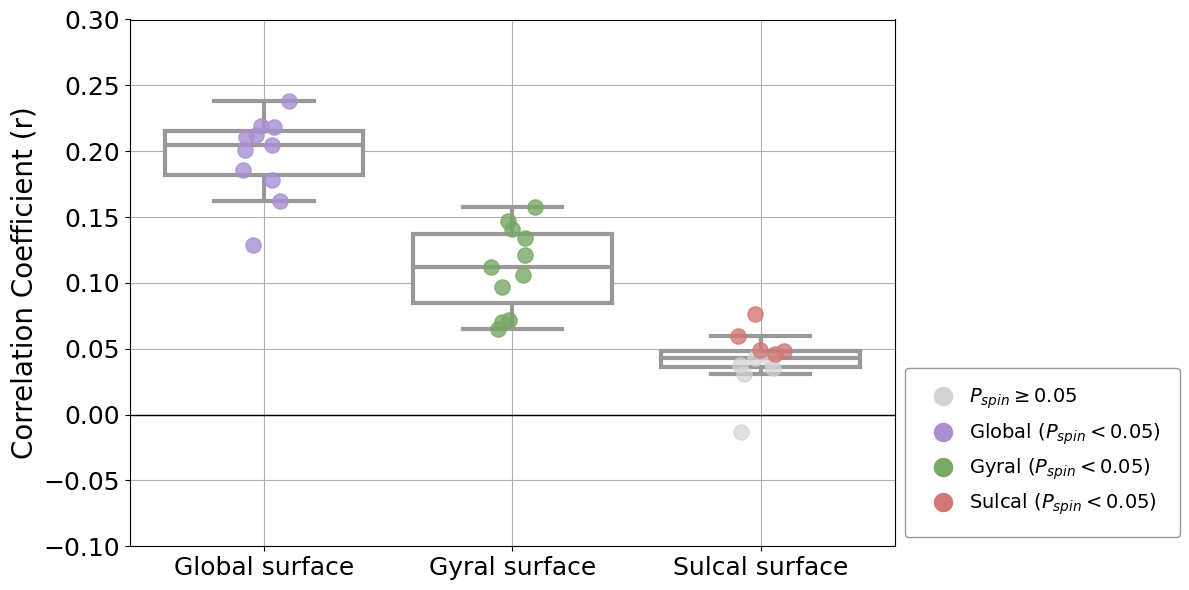

In [17]:
swm_1mm = [0.212, 0.201, 0.186, 0.211, 0.218, 0.238, 0.205, 0.162, 0.178, 0.129, 0.219]
swm_2mm = [0.112, 0.106, 0.097, 0.141, 0.158, 0.147, 0.121, 0.065, 0.07, 0.072, 0.134]
swm_3mm = [0.06, 0.035, 0.038, 0.031, 0.048, 0.041, 0.046, 0.049, 0.043, -0.013, 0.076]
p_1mm = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0,0]
p_2mm = [0, 0, 0, 0, 0, 0, 0, 0.003, 0.003, 0.001, 0]
p_3mm = [0.006, 0.118, 0.06, 0.176, 0.029, 0.067, 0.032, 0.012, 0.051, 0.567, 0.001]

plot_swm_boxplot(swm_1mm, swm_2mm, swm_3mm, p_1mm, p_2mm, p_3mm)

### Long-range fiber - Curvature (SWM 2mm)

/tmp/ipykernel_1805179/3604682467.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


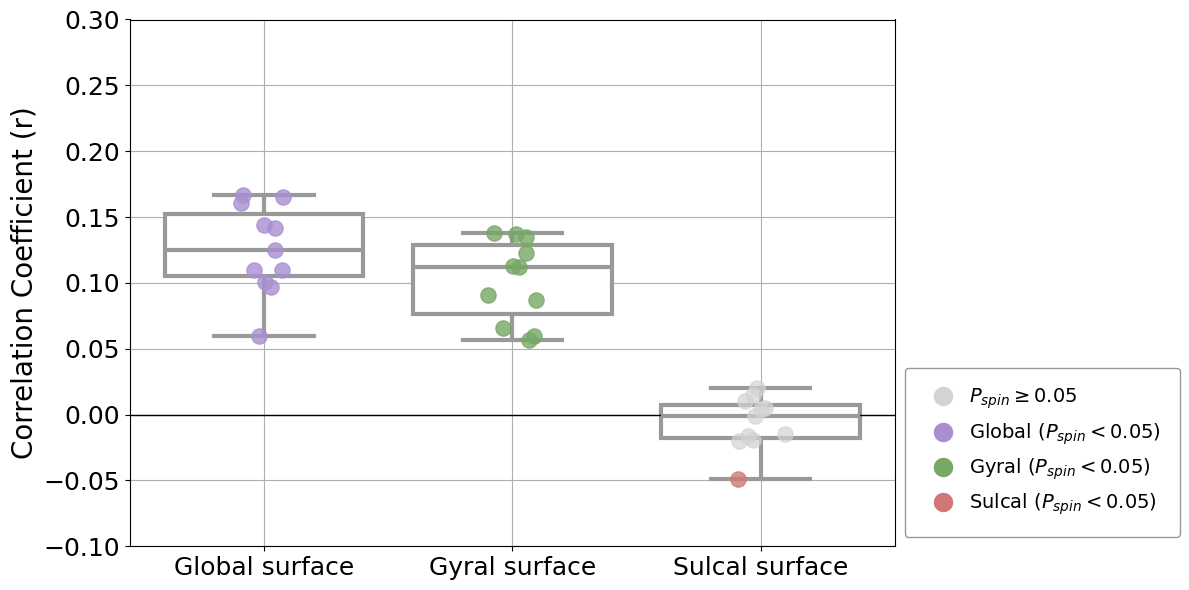

In [15]:
swm_1mm = [0.167, 0.125, 0.110, 0.110, 0.144, 0.161, 0.142, 0.101, 0.097, 0.06, 0.165]
swm_2mm = [0.123, 0.091, 0.087, 0.112, 0.137, 0.135, 0.113, 0.066, 0.057, 0.06, 0.138]
swm_3mm = [0.015, -0.015, -0.02, -0.019, 0.005, -0.001, 0.01, 0.004, -0.016, -0.049, 0.02]
p_1mm = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0,0]
p_2mm = [0, 0, 0, 0, 0, 0, 0, 0, 0.014, 0.01, 0]
p_3mm = [0.463, 0.49, 0.316, 0.404, 0.801, 0.976, 0.642, 0.868, 0.467, 0.033, 0.31]

plot_swm_boxplot(swm_1mm, swm_2mm, swm_3mm, p_1mm, p_2mm, p_3mm)

### U-fibers - Curvature (SWM 1mm)

/tmp/ipykernel_1805179/3604682467.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


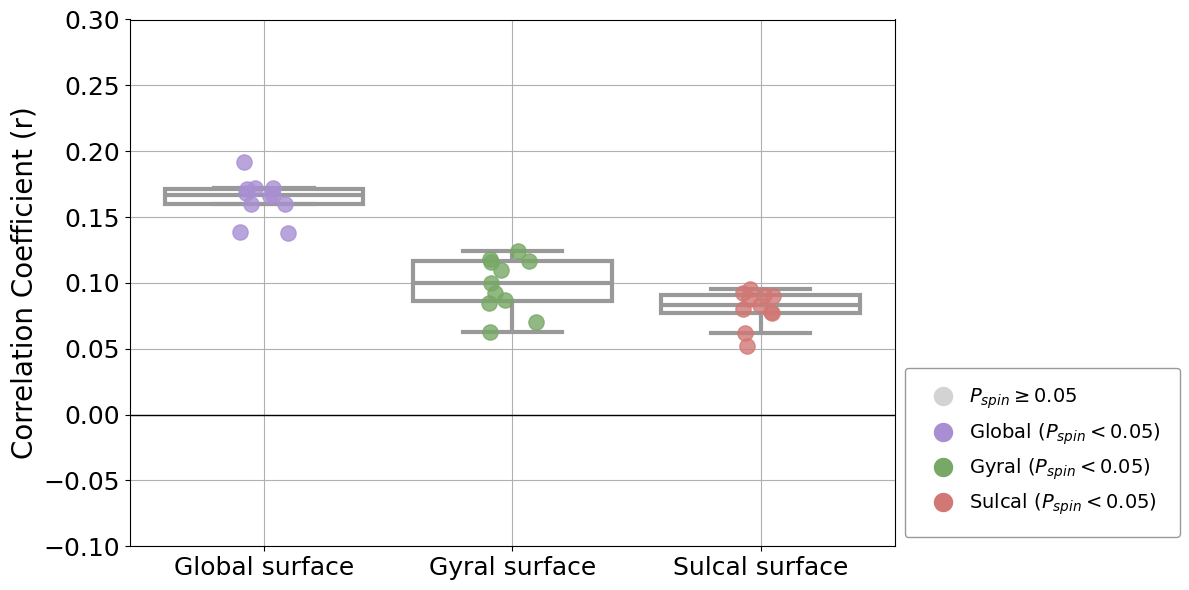

In [18]:
swm_1mm = [0.168, 0.172, 0.172, 0.167, 0.160, 0.138, 0.192, 0.160, 0.171, 0.166, 0.139]
swm_2mm = [0.1, 0.118, 0.116, 0.124, 0.063, 0.07, 0.117, 0.110, 0.092, 0.087, 0.085]
swm_3mm = [0.092, 0.091, 0.078, 0.062, 0.095, 0.088, 0.077, 0.052, 0.083, 0.09, 0.08]
p_1mm = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
p_2mm = [0, 0, 0, 0, 0.002, 0.002, 0, 0, 0, 0, 0]
p_3mm = [0, 0.001, 0.002, 0.01, 0.001, 0, 0.001, 0.01, 0.002, 0.001, 0.001]

plot_swm_boxplot(swm_1mm, swm_2mm, swm_3mm, p_1mm, p_2mm, p_3mm)

### U-fibers - Curvature (SWM 2mm)

/tmp/ipykernel_1805179/3604682467.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


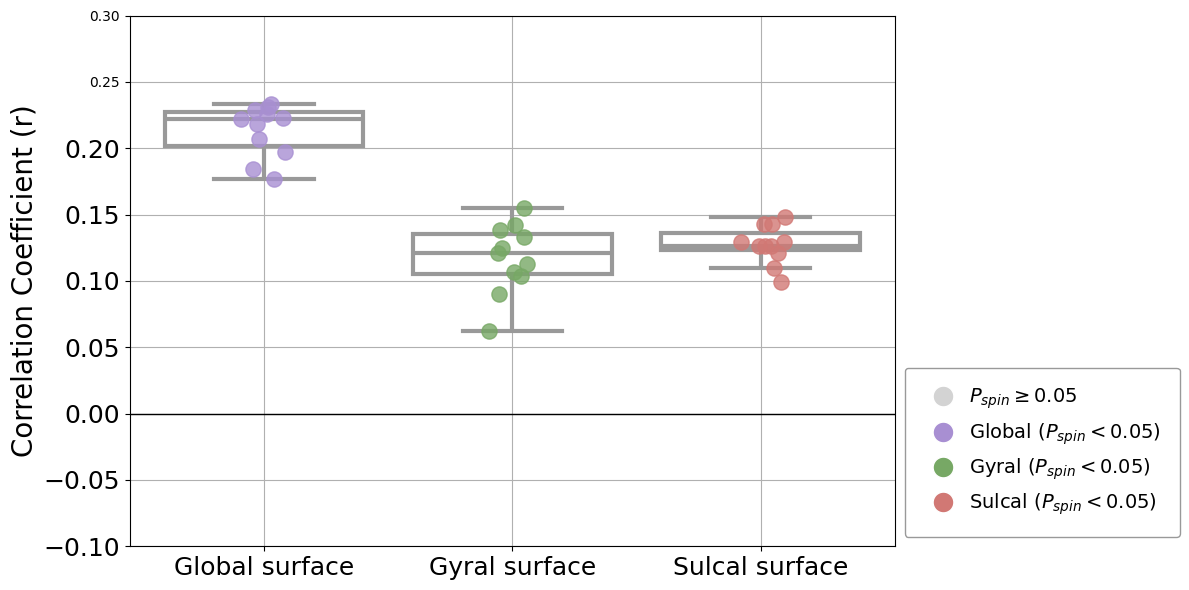

In [16]:
swm_1mm = [0.197, 0.207, 0.229, 0.231, 0.223, 0.184, 0.233, 0.218, 0.222, 0.226, 0.177]
swm_2mm = [0.113, 0.142, 0.133, 0.125, 0.104, 0.062, 0.121, 0.155, 0.09, 0.138, 0.107]
swm_3mm = [0.129, 0.110, 0.143, 0.148, 0.126, 0.129, 0.126, 0.099, 0.143, 0.121, 0.126]
p_1mm = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
p_2mm = [0, 0, 0, 0, 0, 0.008, 0, 0, 0, 0, 0]
p_3mm = [0, 0.001, 0, 0, 0.001, 0, 0, 0.001, 0.001, 0.001, 0]

plot_swm_boxplot(swm_1mm, swm_2mm, swm_3mm, p_1mm, p_2mm, p_3mm)